# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

* Apa faktor-faktor utama yang paling signifikan memicu tingginya tingkat *attrition* di Jaya jaya maju?
* Karakteristik atau kelompok karyawan yang seperti apa yang paling berisiko tinggi untuk keluar?
* Siapa sajakah karyawan yang saat ini memiliki probabilitas tinggi untuk mengundurkan diri dalam waktu dekat?
* Tindakan intervensi atau kebijakan strategis apa yang dapat diambil manajemen HR untuk mencegah *attrition rate* tersebut?
* Metrik kunci (KPI) apa saja yang perlu dipantau secara rutin melalui *Bussines Dashboard*?



- Nama: Marsello Ormanda
- Email: marselloormanda@gmail.com
- Id Dicoding: -

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
!pip install catboost
import joblib

# Manipulasi dan analisis data
import pandas as pd
import numpy as np
from scipy import stats

# Visualisasi data dasar untuk eksplorasi
import matplotlib.pyplot as plt
import seaborn as sns

# Files exporting
from google.colab import files

# Library untuk kepentingan developing model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, recall_score, precision_score, f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

In [2]:
# Mengatur agar semua kolom ditampilkan di Notebook
pd.set_option('display.max_columns', None)

# Mengabaikan peringatan
import warnings
warnings.filterwarnings('ignore')

### Menyiapkan data yang akan digunakan

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Marsello-or/Belajar_Penerapan_Data_Science/refs/heads/main/employee_data.csv")

# Menampilkan bahwa data berhasil dimuat
print(f"Data berhasil dimuat dengan jumlah {df.shape[0]} baris dan {df.shape[1]} kolom.")

Data berhasil dimuat dengan jumlah 1470 baris dan 35 kolom.


## Data Understanding

In [4]:
# Melihat gambaran besar data
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,4,Male,88,3,1,Human Resources,2,Married,2991,5224,0,Y,Yes,11,3,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,1,Female,61,1,2,Healthcare Representative,2,Married,4777,14382,5,Y,No,15,3,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,1,Male,34,3,1,Research Scientist,3,Married,2461,10332,9,Y,Yes,12,3,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,3,Female,77,3,4,Sales Executive,2,Married,13525,14864,5,Y,No,14,3,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,3,Female,98,3,1,Research Scientist,3,Married,2001,12549,2,Y,No,14,3,2,80,3,20,2,3,5,3,0,2


In [5]:
# Memeriksa tipe data dan mendeteksi kolom secara umum
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [6]:
# Memeriksa apakah ada missing values pada dataset yang digunakan
print(df.isnull().sum(0))

EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtC

In [7]:
# Memeriksa duplikasi data pada dataset
print(df.duplicated().sum())

0


### Hasil Penilaian Kualitas Data
---
Karakteristik umum dataset: Dataset jaya jaya maju memilik total 1.470 baris dan 35 kolom. Secara umum dataset ini berisi kombinasi data demografi karyawan seperti usia, jenis kelamin, status pernikahan), data historis pekerjaan (seperti departemen, peran, masa kerja), serta tingkat kepuasan kerja mereka.

Berdasarkan pengecekan awal dan pengecekan duplikasi, ditemukan beberapa point penting berikut:
- Data duplikat: tidak ditemukan adanya data baris yang terduplikasi
- Kolom redundant: Terdapat kolom seperti employeecount, over18, dan standardhours yang nilainya sama untuk semua baris. Beberapa kolom ini tidak akan memberikan informasi tambahan untuk analisis karena bernilai sama.
- Kolom attrition yang bertindak sebagai label/target utama dalam proyek ini memiliki masalah missing values. Dari total 1.470 baris kolom Aattrition hanya terisi sebanyak 1.058 baris, yang berarti ada 412 baris yang kosong, selain itu tipe datanya terbaca sebagai float64 yang mengindikasikan datanya berupa numerik.

Kategori data yang didapatkan sebagai berikut:
|Kategori Data| Nama Kolom|
|---|---|
|Identitas & Target|EmployeeId, Attrition|
|Demografi Karyawan|Age, Gender, MaritalStatus, Over18|
|Kompensasi dan Finansial|DailyRate, HourlyRate, MonthlyIncome, MonthlyRate, PercentSalaryHike, StockOptionLevel|
|Historis Pekerjaan| Department, JobRole, JobLevel, BusinessTravel, DistanceFromHome, OverTime|
|Masa Kerja|TotalWorkingyearsm, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager|
|Edukasi dan Pelatihan| Education, EducationField, TrainingTimesLastYear|
|Kepuasan dan Performa| EnvironmentSatisfaction, JobInvolvement, JobSatisfaction, PerformanceRating, RelationshipSatisfaction, WorkLifeBalance|
|Konstan/Tidak Berguna|EmployeeCount, StandardHours|

In [8]:
# Memeriksa nilai unik dan distriusi data pada kolom target "Attrition"
print(df['Attrition'].value_counts(dropna=False))

Attrition
0.0    879
NaN    412
1.0    179
Name: count, dtype: int64


In [9]:
print("\nStatistik Deskriptif Kolom Numerik: ")
df.describe()


Statistik Deskriptif Kolom Numerik: 


,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
print("\nStatistik Deskriptif Kolom Kategorik: ")
df.describe(include=['object'])


Statistik Deskriptif Kolom Kategorik: 


,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470
unique,3,3,6,2,9,3,1,2
top,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1043,961,606,882,326,673,1470,1054


In [11]:
# Menampilkan nilai unik spesifik dari setiap kolom kategorikal
categorical_cols = df.select_dtypes(include=['object']).columns

print("Nilai unik pada setiap kolom kategorikal:")
for col in categorical_cols:
  print(f"\nKolom {col}:")
  print(df[col].unique())

Nilai unik pada setiap kolom kategorikal:

Kolom BusinessTravel:
['Travel_Frequently' 'Travel_Rarely' 'Non-Travel']

Kolom Department:
['Human Resources' 'Research & Development' 'Sales']

Kolom EducationField:
['Other' 'Medical' 'Life Sciences' 'Marketing' 'Technical Degree'
 'Human Resources']

Kolom Gender:
['Male' 'Female']

Kolom JobRole:
['Human Resources' 'Healthcare Representative' 'Research Scientist'
 'Sales Executive' 'Manager' 'Laboratory Technician' 'Research Director'
 'Manufacturing Director' 'Sales Representative']

Kolom MaritalStatus:
['Married' 'Single' 'Divorced']

Kolom Over18:
['Y']

Kolom OverTime:
['Yes' 'No']


### Ringkasan Statistik Deskriptif Kolom Numerik
---

*   **Jumlah (Count)**: Menunjukkan jumlah entri non-null untuk setiap kolom. Dalam kasus ini, sebagian besar kolom memiliki 1470 entri, kecuali kolom `Attrition` yang hanya memiliki 1058 entri, mengindikasikan adanya nilai yang hilang (missing values).
*   **Rata-rata (Mean)**: Nilai rata-rata dari setiap kolom. Contohnya:
    *   `Age` (Usia): Rata-rata usia karyawan adalah sekitar 36.9 tahun.
    *   `Attrition`: Rata-rata 0.169, yang berarti sekitar 16.9% dari data yang tidak kosong menunjukkan *attrition* (karyawan keluar).
    *   `MonthlyIncome`: Rata-rata pendapatan bulanan adalah sekitar 6502.93.
*   **Standar Deviasi (Std)**: Mengukur sebaran atau dispersi data dari rata-ratanya. Nilai standar deviasi yang tinggi menunjukkan sebaran data yang lebih luas.
    *   `MonthlyIncome` memiliki standar deviasi yang cukup tinggi (4707.95), menunjukkan variasi pendapatan yang signifikan di antara karyawan.
    *   `Age` memiliki standar deviasi sekitar 9.13, menunjukkan variasi usia yang moderat.
*   **Nilai Minimum (Min)** dan **Maksimum (Max)**: Menunjukkan nilai terendah dan tertinggi dalam setiap kolom.
    *   `Age` berkisar antara 18 hingga 60 tahun.
    *   `DailyRate` (Tingkat Harian) berkisar antara 102 hingga 1499.
    *   `TotalWorkingYears` (Total Tahun Bekerja) berkisar dari 0 hingga 40 tahun.
*   **Kuartil (25%, 50%, 75%)**: Memberikan informasi tentang distribusi data.
    *   `50% (median)` adalah nilai tengah. Misalnya, median `MonthlyIncome` adalah 4919, yang lebih rendah dari rata-ratanya (6502.93), menunjukkan distribusi pendapatan yang mungkin condong ke arah kanan (pendapatan yang lebih tinggi memiliki frekuensi lebih rendah).
    *   `25%` menunjukkan bahwa 25% data berada di bawah nilai tersebut.
    *   `75%` menunjukkan bahwa 75% data berada di bawah nilai tersebut.

### Ringkasan Statistik Deskriptif Kolom Kategorikal
---

Berikut adalah poin-poin penting dari ringkasan ini:

*   **BusinessTravel (Perjalanan Bisnis)**:
    *   Terdapat 3 kategori unik: `Travel_Rarely`, `Travel_Frequently`, dan `Non-Travel`.
    *   Sebagian besar karyawan (`1043` dari 1470) melakukan perjalanan `Travel_Rarely` (Jarang Bepergian), menunjukkan bahwa mayoritas karyawan tidak sering melakukan perjalanan bisnis.

*   **Department (Departemen)**:
    *   Terdapat 3 departemen unik: `Research & Development`, `Sales`, dan `Human Resources`.
    *   Departemen `Research & Development` adalah yang terbesar dengan `961` karyawan.

*   **EducationField (Bidang Pendidikan)**:
    *   Terdapat 6 bidang pendidikan unik: `Life Sciences`, `Medical`, `Marketing`, `Technical Degree`, `Human Resources`, dan `Other`.
    *   `Life Sciences` adalah bidang pendidikan paling dominan dengan `606` karyawan.

*   **Gender (Jenis Kelamin)**:
    *   Terdapat 2 kategori unik: `Male` dan `Female`.
    *   Jumlah karyawan `Male` (`882`) lebih banyak dibandingkan `Female`.

*   **JobRole (Peran Pekerjaan)**:
    *   Terdapat 9 peran pekerjaan unik, seperti `Sales Executive`, `Research Scientist`, `Laboratory Technician`, dll.
    *   `Sales Executive` adalah peran pekerjaan yang paling umum dengan `326` karyawan.

*   **MaritalStatus (Status Pernikahan)**:
    *   Terdapat 3 status pernikahan unik: `Married`, `Single`, dan `Divorced`.
    *   Status `Married` adalah yang paling banyak dengan `673` karyawan.

*   **Over18 (Diatas 18 Tahun)**:
    *   Hanya memiliki 1 nilai unik: `Y`.
    *   Ini menunjukkan bahwa semua karyawan dalam dataset berusia di atas 18 tahun, sehingga kolom ini tidak memberikan variasi informasi yang berarti dan mungkin dapat dihapus dalam analisis lebih lanjut.

*   **OverTime (Lembur)**:
    *   Terdapat 2 kategori unik: `No` dan `Yes`.
    *   Mayoritas karyawan (`1054`) tidak melakukan `OverTime` (Lembur).

## Univariate Analysis
---

Sebaran asli kolom attrition:
Attrition
0.0    879
NaN    412
1.0    179
Name: count, dtype: int64


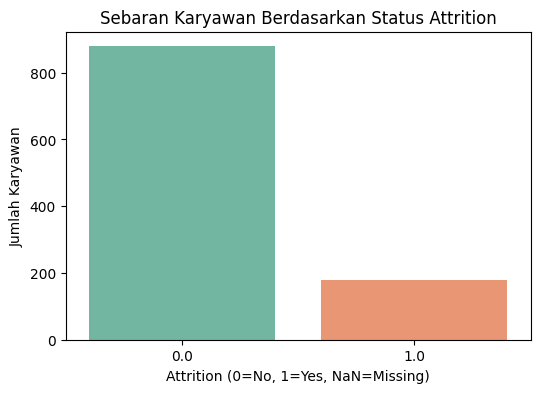

In [12]:
print("Sebaran asli kolom attrition:")
print(df['Attrition'].value_counts(dropna=False))

# Visualisasi sebaran target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette='Set2')
plt.title('Sebaran Karyawan Berdasarkan Status Attrition')
plt.xlabel('Attrition (0=No, 1=Yes, NaN=Missing)')
plt.ylabel('Jumlah Karyawan')
plt.show()

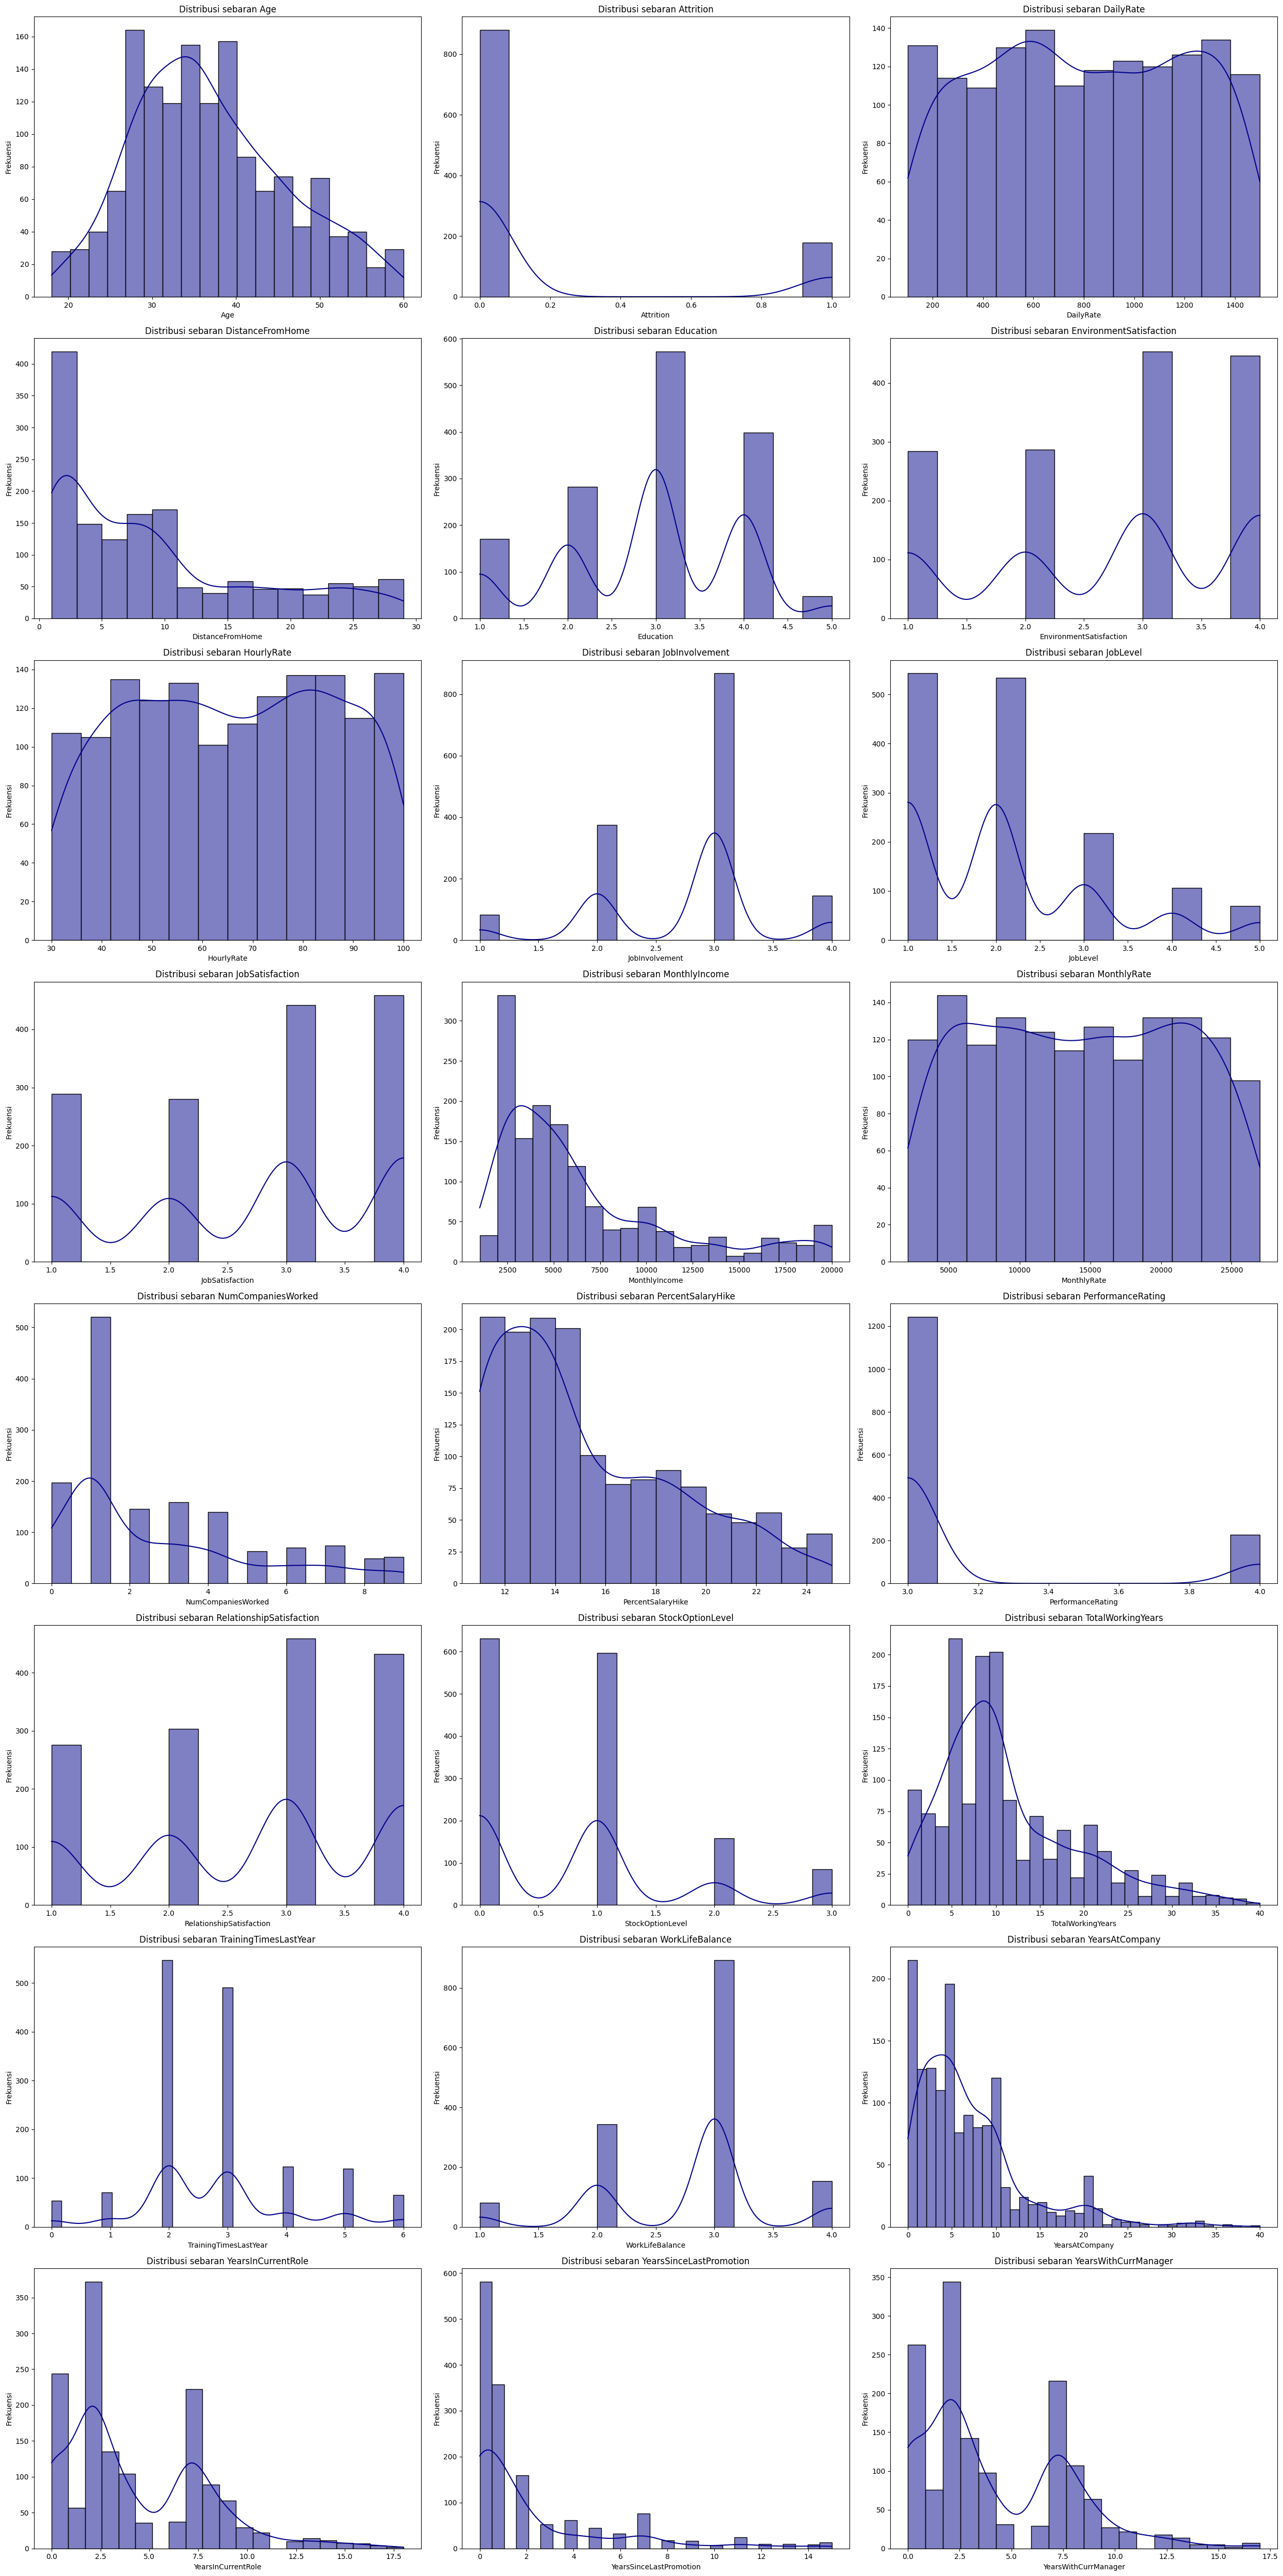

In [13]:
sample_numerical = df.select_dtypes(include=['int64', 'float64']).columns
sample_numerical = sample_numerical.drop(['EmployeeId', 'EmployeeCount', 'StandardHours'])

fig, axes = plt.subplots(8,3, figsize=(25, 50))
axes = axes.flatten()

for i, col in enumerate(sample_numerical):
  sns.histplot(df[col], kde=True, ax=axes[i], color='darkblue')
  axes[i].set_title(f'Distribusi sebaran {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

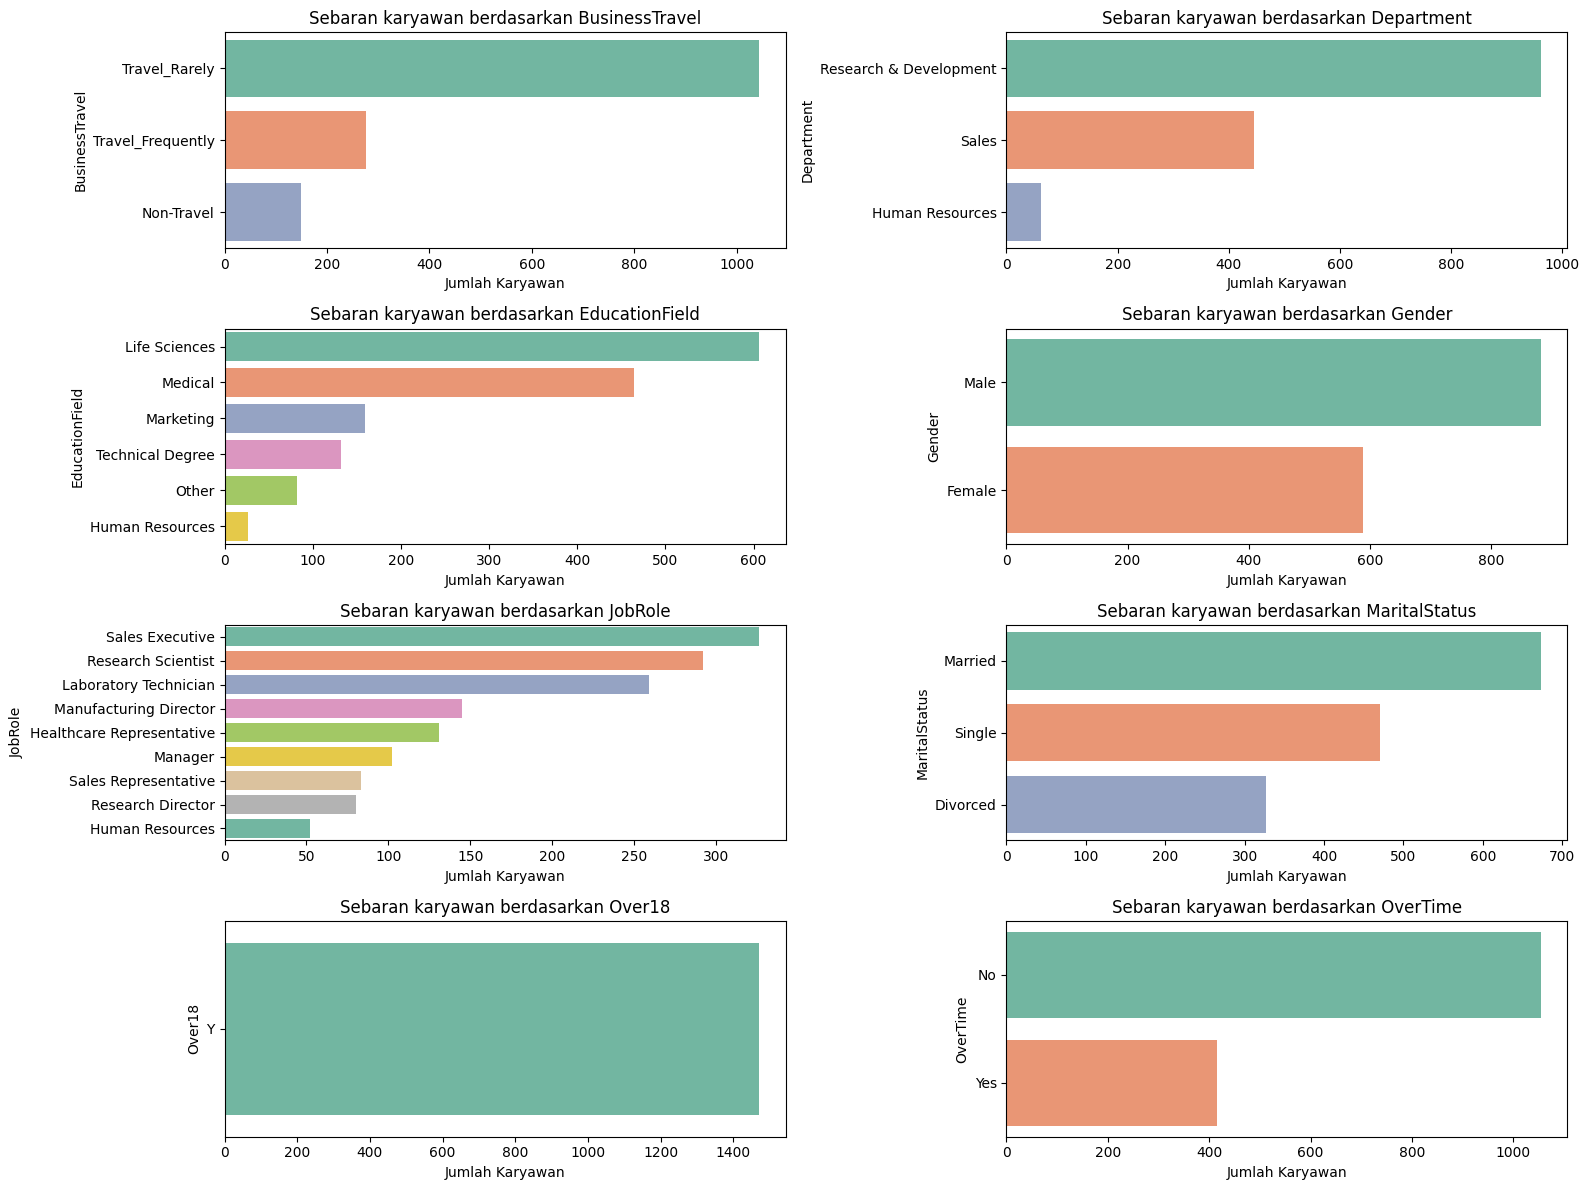

In [14]:
sample_categorical = df.select_dtypes(include=['object']).columns

fix, axes = plt.subplots(4,2, figsize=(16,12))
axes = axes.flatten()

for i, col in enumerate(sample_categorical):
  sns.countplot(data=df, y=col, ax=axes[i], order=df[col].value_counts().index, palette='Set2')
  axes[i].set_title(f'Sebaran karyawan berdasarkan {col}')
  axes[i].set_xlabel('Jumlah Karyawan')
  axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


## Kesimpulan Analisis Univariat

Analisis univariat telah memberikan gambaran awal yang krusial mengenai distribusi setiap variabel dalam dataset. Berikut adalah poin-poin kunci yang perlu ditekankan:

### Kolom Numerik:

*   **MonthlyIncome:** Distribusi `MonthlyIncome` sangat *right-skewed* (condong ke kanan), menunjukkan bahwa mayoritas karyawan memiliki pendapatan bulanan yang relatif rendah, dengan sebagian kecil memiliki pendapatan yang sangat tinggi. Perbedaan antara rata-rata (6502.93) dan median (4919) memperkuat indikasi adanya ketidakseimbangan.
*   **Variabel Masa Kerja (TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager):** Sebagian besar kolom yang berhubungan dengan masa kerja dan pengalaman cenderung *right-skewed*, mengindikasikan bahwa mayoritas karyawan memiliki masa kerja, masa jabatan, atau pengalaman di posisi saat ini yang relatif singkat. Ini bisa menjadi pertanda adanya potensi *turnover* karyawan yang tinggi.

### Kolom Kategorikal:

*   **Attrition (Kolom Target):** Ini adalah poin paling kritis. Kolom `Attrition` memiliki **412 *missing values*** dari total 1470 baris. Selain itu, terdapat **ketidakseimbangan kelas yang signifikan** pada data yang tidak kosong (879 'No' vs 179 'Yes'). Hal ini akan menjadi tantangan besar dalam *modeling* dan memerlukan strategi penanganan khusus (misalnya, imputasi untuk *missing values* dan teknik *resampling* untuk ketidakseimbangan kelas).
*   **Over18:** Kolom ini hanya memiliki satu nilai unik ('Y'), menunjukkan bahwa semua karyawan berusia di atas 18 tahun. Oleh karena itu, kolom ini **tidak memberikan informasi yang bervariasi** dan dapat dipertimbangkan untuk dihapus dalam tahap *data preparation*.
*   **Distribusi Kategorikal Lainnya:** Observasi pada kolom seperti `Department`, `JobRole`, `MaritalStatus`, dan `BusinessTravel` menunjukkan kategori mayoritas yang jelas. Misalnya, `Research & Development` adalah departemen terbesar, `Sales Executive` adalah peran pekerjaan dominan, dan mayoritas karyawan `Married` serta `Travel_Rarely`.

## Data Preparation / Preprocessing

In [15]:
# Menghapus baris yang memiliki missing value pada kolom target 'Attrition'
df_clean = df.dropna(subset=['Attrition']).copy()

# Menghapus kolom non informatif dari analisis univariat
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18']
df_clean = df_clean.drop(cols_to_drop, axis=1)

In [16]:
# Membuat salinan khusus untuk kebutuhan dashboard di looker studio
df_looker = df_clean.copy()

# Melakukan mapping format pada df_looker agar ramah pengguna di dashboard
df_looker['Attrition'] = df_looker['Attrition'].map({1.0: 'Yes', 0.0: 'No'})

# Mengubah angka skala ordinal menjadi teks sesuai kamus data
education_map = {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}
satisfaction_map = {1:'Low', 2:'Medium', 3:'High', 4:'Very High'}
performance_map = {1:'Low', 2:'Good', 3:'Excellent', 4:'Outstanding'}
wlb_map = {1:'Low', 2:'Good', 3:'Excellent', 4:'Outstanding'}

df_looker['Education'] = df_looker['Education'].map(education_map)
df_looker['EnvironmentSatisfaction'] = df_looker['EnvironmentSatisfaction'].map(satisfaction_map)
df_looker['JobInvolvement'] = df_looker['JobInvolvement'].map(satisfaction_map)
df_looker['JobSatisfaction'] = df_looker['JobSatisfaction'].map(satisfaction_map)
df_looker['PerformanceRating'] = df_looker['PerformanceRating'].map(performance_map)
df_looker['RelationshipSatisfaction'] = df_looker['RelationshipSatisfaction'].map(satisfaction_map)
df_looker['WorkLifeBalance'] = df_looker['WorkLifeBalance'].map(wlb_map)

print(f"Ukuran df_clean untuk bivariate analysis dan modeling: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")
print(f"Ukuran df_looker untuk dashboard: {df_looker.shape[0]} baris, {df_looker.shape[1]} kolom")
print(f"Sisa missing values pada kolom target: {df_clean['Attrition'].isnull().sum()}")

Ukuran df_clean untuk bivariate analysis dan modeling: 1058 baris, 32 kolom
Ukuran df_looker untuk dashboard: 1058 baris, 32 kolom
Sisa missing values pada kolom target: 0


## Bivariate / Multivariate Analysis (Explanatory)
---

### Screening Massal Data Kualitatif

In [17]:
categorical_cols = df_clean.select_dtypes(include=['object']).columns

for col in categorical_cols:
  if col != 'Attrtition':
    summary = df_clean.groupby(col)['Attrition'].agg(['count', 'mean']).reset_index()
    summary['Attrition_Rate (%)'] = (summary['mean'] * 100).round(2)
    summary = summary.rename(columns={'count': 'Total_Karyawan'}).drop(columns=['mean'])

    summary = summary.sort_values(by='Attrition_Rate (%)', ascending=False)

    print(f"\n Analisis berdasarkan: {col}")
    print(summary.to_string(index=False))


 Analisis berdasarkan: BusinessTravel
   BusinessTravel  Total_Karyawan  Attrition_Rate (%)
Travel_Frequently             205               24.88
    Travel_Rarely             746               15.68
       Non-Travel             107               10.28

 Analisis berdasarkan: Department
            Department  Total_Karyawan  Attrition_Rate (%)
                 Sales             319               20.69
       Human Resources              38               15.79
Research & Development             701               15.26

 Analisis berdasarkan: EducationField
  EducationField  Total_Karyawan  Attrition_Rate (%)
Technical Degree              96               26.04
       Marketing             122               21.31
           Other              59               16.95
   Life Sciences             436               16.06
         Medical             330               13.94
 Human Resources              15               13.33

 Analisis berdasarkan: Gender
Gender  Total_Karyawan  Attrition

### Screening Massal Data Kuantitatif
Analisis keseluruhan data kuantitatif dan juga uji signifikansi

In [18]:
#1. Hitung rata-rata berdasarkan kelompok attrition
numeric_summary = df_clean.groupby('Attrition').mean(numeric_only=True).T
numeric_summary.columns = ['Rata2_karyawan_stay (0)', 'Rata2_karyawan_resign (1)']

#2. Hitung Persentase Perubahan Relatif
numeric_summary["Perubahan_Relatif (%)"] = ((numeric_summary["Rata2_karyawan_stay (0)"] - numeric_summary["Rata2_karyawan_resign (1)"]).abs() / numeric_summary["Rata2_karyawan_stay (0)"]) * 100

#3. Hitung Korelasi Linier langsung terhadap attrition
df_corr_check = df_clean.copy()
df_corr_check["Attrition"] = df_corr_check["Attrition"].astype(float)
correlations = df_corr_check.corr(numeric_only=True)['Attrition']

numeric_summary["Korelasi_Pearson"] = correlations
numeric_summary = numeric_summary.drop(index='Attrition', errors='ignore')

#4. Hitung uji signifikansi statistik (p-value menggunakan mann-whitney U test)
p_values = []
for col in numeric_summary.index:
  group_stay = df_clean[df_clean['Attrition'] == 0][col]
  group_resign = df_clean[df_clean['Attrition'] == 1][col]

  stat, p_val = stats.mannwhitneyu(group_stay, group_resign, alternative='two-sided')
  p_values.append(p_val)

numeric_summary["P-Value"]  = p_values

#5. Kesimpulan status signifikansi
numeric_summary['Signifikan_secara_statistik'] = numeric_summary['P-Value'].apply(lambda x: 'Ya (p < 0.05)' if x < 0.05 else 'Tidak')

#6. Tampilan hasil akhir berdasarkan perubahan relatif tertinggi
numeric_summary_final = numeric_summary.sort_values(by='Perubahan_Relatif (%)', ascending=False)
print(numeric_summary_final.round(4).to_string())

                          Rata2_karyawan_stay (0)  Rata2_karyawan_resign (1)  Perubahan_Relatif (%)  Korelasi_Pearson  P-Value Signifikan_secara_statistik
StockOptionLevel                           0.8248                     0.4581                44.4593           -0.1642   0.0000               Ya (p < 0.05)
YearsWithCurrManager                       4.3959                     2.8994                34.0422           -0.1560   0.0000               Ya (p < 0.05)
YearsInCurrentRole                         4.5199                     2.9888                33.8742           -0.1588   0.0000               Ya (p < 0.05)
TotalWorkingYears                         12.0762                     8.2905                31.3485           -0.1771   0.0000               Ya (p < 0.05)
YearsAtCompany                             7.4471                     5.1899                30.3092           -0.1351   0.0000               Ya (p < 0.05)
MonthlyIncome                           6982.9283                  487

## Laporan Hasil Skrining Awal: Variabel Kualitatif & Kuantitatif

Tahap skrining massal telah dilakukan untuk memetakan seluruh variabel independen terhadap target variabel (`Attrition`). Proses ini menggabungkan pendekatan bisnis (Rasio Attrition Internal) dan pembuktian saintifik (Korelasi Pearson serta Uji Statistik Non-Parametrik Mann-Whitney U) untuk mengunci variabel yang valid secara signifikan memicu *attrition* di Jaya Jaya Maju.

---

### 1. Analisis Faktor Kualitatif (Kategorikal)

Skrining pada variabel kualitatif dihitung berdasarkan **Rasio Attrition Internal kelompok** (Jumlah Resign di kelompok tersebut / Total Karyawan di kelompok tersebut). Berdasarkan target manajemen untuk menjaga *attrition rate* di bawah **10%**, ditemukan beberapa "Tersangka Utama" yang berada jauh di zona bahaya:

* **Budaya Lembur (`OverTime`):** Karyawan yang mendapatkan kebijakan lembur memiliki *attrition rate* sebesar **31.92%** (hampir 3x lipat dibandingkan karyawan yang tidak lembur, yaitu 10.79%). Faktor ini diidentifikasi sebagai indikator utama terjadinya *burnout* atau kejenuhan kerja.
* **Kerentanan Peran Kerja (`JobRole`):** Posisi **Sales Representative** berada dalam kondisi paling kritis dengan *attrition rate* mencapai **43.10%**, disusul oleh posisi teknis laboratorium (**Laboratory Technician**) sebesar **26.06%**. Sebaliknya, posisi struktural seperti *Manager* (6.33%) dan *Research Director* (3.23%) berada di zona sangat aman.
* **Status Pernikahan (`MaritalStatus`):** Karyawan dengan status **Single** memiliki kecenderungan keluar jauh lebih tinggi (**26.70%**) dibandingkan dengan karyawan yang Married (13.36%) atau Divorced (9.50%).
* **Intensitas Perjalanan Dinas (`BusinessTravel`):** Karyawan yang ditugaskan untuk sering bepergian (*Travel_Frequently*) mencatatkan angka *attrition* **24.88%**, mengonfirmasi adanya beban fisik/kelelahan ekstra akibat mobilitas tinggi.

---

### 2. Analisis Faktor Kuantitatif (Numerik) & Justifikasi Statistik

Untuk menghindari bias skala data (seperti membandingkan satuan ribuan dolar pada gaji dengan satuan tahun pada umur), analisis kuantitatif menggunakan indeks **Perubahan Relatif (%)** terhadap rata-rata karyawan loyal (`Stay`), diperkuat oleh **Korelasi Pearson** dan **Uji Mann-Whitney U**.

Uji Mann-Whitney U dipilih sebagai *best practice* karena mayoritas data numerik bersifat *right-skewed* (tidak berdistribusi normal) dan mencakup skala ordinal. Hasil pengujian mengelompokkan variabel menjadi dua kategori:

#### A. Faktor yang Terbukti Signifikan Secara Statistik ($p < 0.05$)
Variabel-variabel di bawah ini memiliki nilai $p = 0.0000$ (sangat signifikan), yang membuktikan secara ilmiah bahwa perbedaan karakteristik antara kelompok yang bertahan dan keluar bukan terjadi karena kebetulan acak:

1.  **`StockOptionLevel` (Perubahan Relatif: 44.46% | Corr: -0.1642):** Karyawan yang bertahan memiliki kepemilikan saham hampir 2x lipat lebih tinggi ($0.82$) dibandingkan mereka yang keluar ($0.45$). Kepemilikan saham (*stock option*) terbukti menjadi instrumen penahan (*retention anchor*) terkuat perusahaan.
2.  **Kesenjangan Kompensasi & Jabatan (`MonthlyIncome` & `JobLevel`):** Terdapat perbedaan relatif pendapatan sebesar **30.22%**. Rata-rata gaji karyawan loyal adalah **\$6.982**, sedangkan kelompok yang *resign* rata-rata hanya bergaji **\$4.872** dan didominasi oleh golongan jabatan rendah (`JobLevel` turun 23.54%).
3.  **Faktor Hubungan Atasan langsung (`YearsWithCurrManager`):** Karyawan yang keluar memiliki masa kerja bersama manajer saat ini yang jauh lebih singkat (**2.89 tahun** vs **4.39 tahun** atau jomplang 34.04%). Ini mengindikasikan adanya friksi atau kegagalan adaptasi pada fase awal penugasan di bawah atasan baru.
4.  **Masa Kerja & Kematangan Usia (`TotalWorkingYears`, `YearsAtCompany`, `Age`):** Kelompok karyawan yang keluar memiliki total pengalaman kerja yang lebih pendek (8.2 tahun vs 12 tahun) dan rata-rata berusia lebih muda (33 tahun vs 37 tahun).
5.  **Jarak Rumah ke Kantor (`DistanceFromHome` | Perubahan: 19.25% | Corr: +0.0781):** Menjadi **satu-satunya variabel numerik signifikan yang memiliki korelasi positif**. Artinya, semakin jauh jarak rumah karyawan dari kantor (rata-rata kelompok resign = 10.3 km vs kelompok stay = 8.6 km), semakin tinggi pula urgensi mereka untuk mengundurkan diri.

#### B. "Plot Twist" Analisis: Faktor yang TIDAK Signifikan ($p > 0.05$)
Skrining statistik berhasil menggugurkan asumsi awam dengan membuktikan bahwa variabel-variabel berikut **TIDAK memiliki pengaruh nyata** terhadap keputusan *attrition* di Jaya Jaya Maju:
* **`PercentSalaryHike` ($p = 0.9799$) & `PerformanceRating` ($p = 0.8011$):** Besaran persentase kenaikan gaji tahunan dan penilaian rapor kinerja karyawan terbukti flat dan sama sekali tidak membedakan orang yang keluar maupun bertahan.
* **`YearsSinceLastPromotion` ($p = 0.0898$):** Karyawan tidak buru-buru keluar karena masalah keterlambatan promosi jabatan.
* **`WorkLifeBalance` ($p = 0.1149$):** Secara angka individu tidak signifikan, karena efek kelelahannya sudah terserap habis secara lebih ekstrem pada variabel kategorikal `OverTime` (Lembur).

---

### Kesimpulan Komponen untuk Tahap Deep-Dive

Berdasarkan hasil skrining makro ini, proses eksplorasi lanjutan akan difokuskan secara efisien hanya pada **variabel-variabel** yang terbukti sahih secara statistik, guna meramu rekomendasi kebijakan HR yang tepat sasaran.

## Deep-Dive Analysis

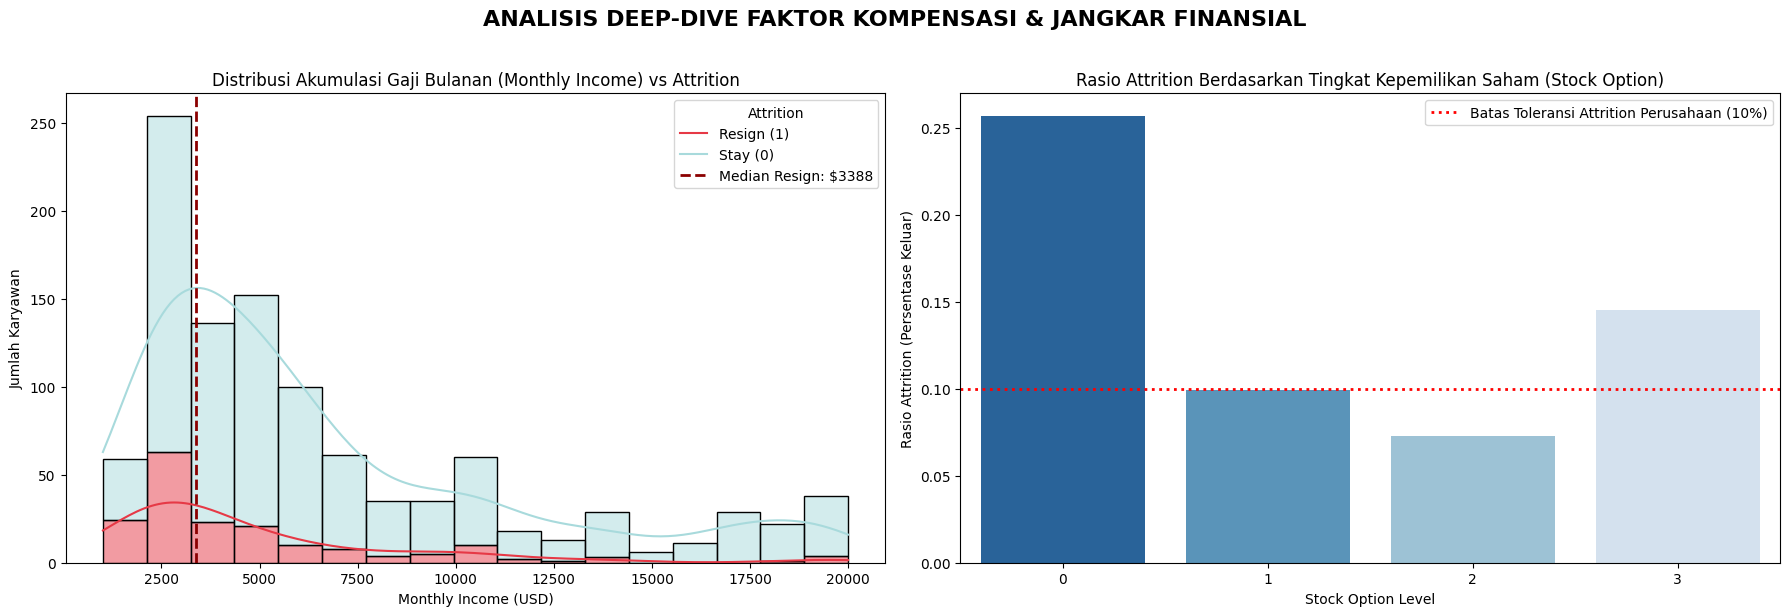

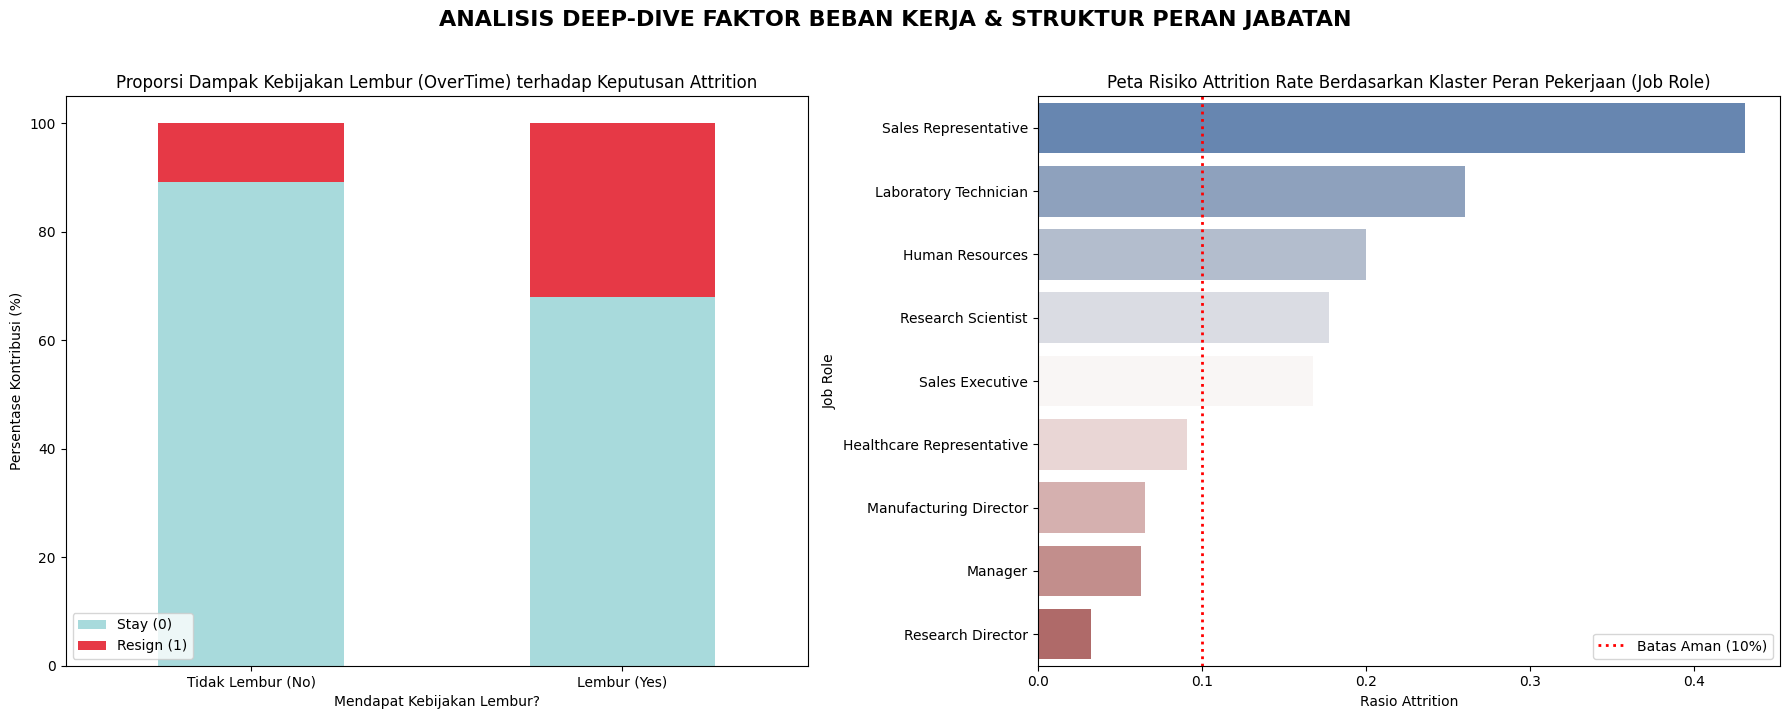

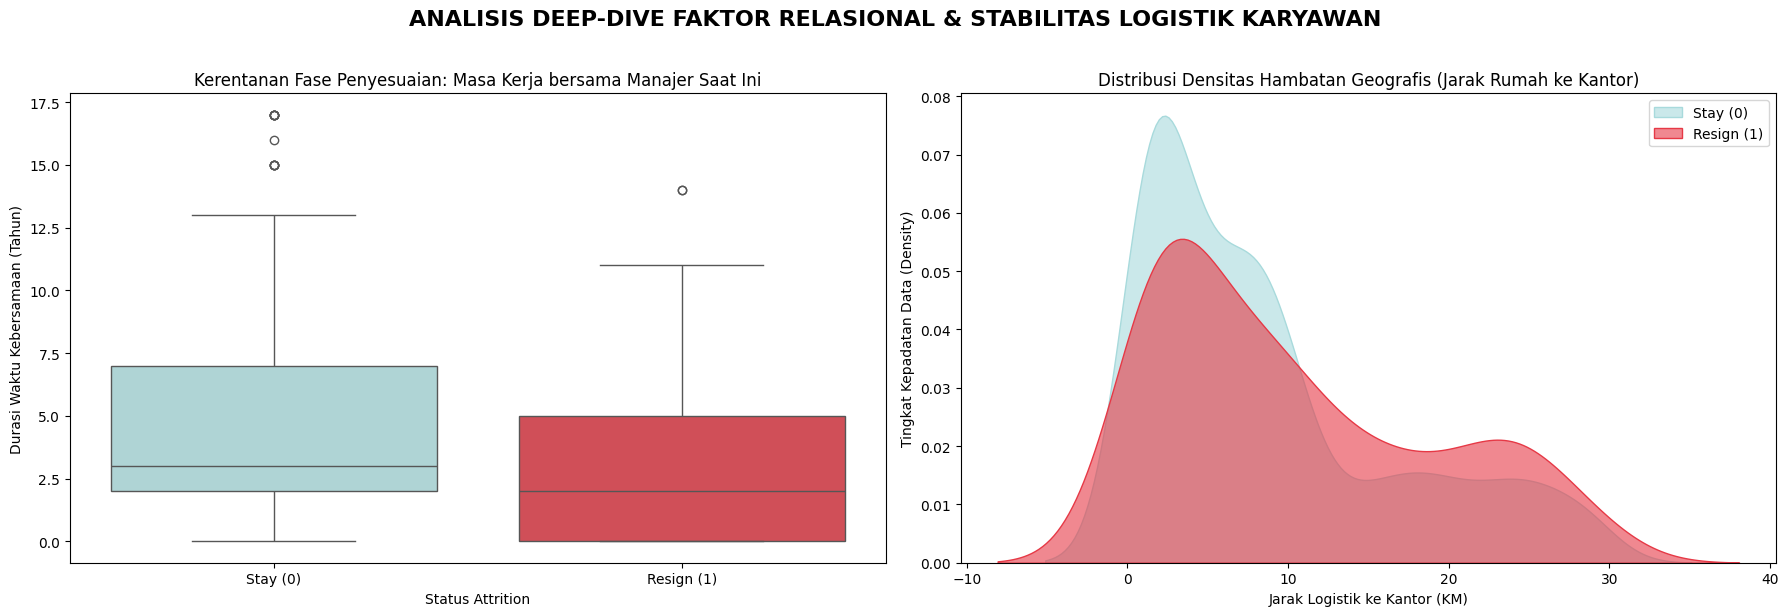

In [19]:
# FIGUR 1: DEEP-DIVE FAKTOR KOMPENSASI & INSENTIF FINANSIAL

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1A: Distribusi Pendapatan Bulanan dengan Penanda Median
sns.histplot(data=df_clean, x='MonthlyIncome', hue='Attrition', kde=True,
             palette=['#a8dadc', '#e63946'], multiple="stack", ax=axes[0])
# Tambahkan garis median kelompok resign untuk memperkuat insight bisnis
median_resign = df_clean[df_clean['Attrition']==1]['MonthlyIncome'].median()
axes[0].axvline(median_resign, color='darkred', linestyle='--', linewidth=2,
                label=f'Median Resign: ${median_resign:.0f}')
axes[0].set_title('Distribusi Akumulasi Gaji Bulanan (Monthly Income) vs Attrition')
axes[0].set_xlabel('Monthly Income (USD)')
axes[0].set_ylabel('Jumlah Karyawan')
axes[0].legend(title='Attrition', labels=['Resign (1)', 'Stay (0)', f'Median Resign: ${median_resign:.0f}'])

# Plot 1B: Hubungan Kepemilikan Saham terhadap Rasio Keluar
sns.barplot(data=df_clean, x='StockOptionLevel', y='Attrition', errorbar=None,
            palette='Blues_r', ax=axes[1])
axes[1].axhline(y=0.10, color='red', linestyle=':', linewidth=2, label='Batas Toleransi Attrition Perusahaan (10%)')
axes[1].set_title('Rasio Attrition Berdasarkan Tingkat Kepemilikan Saham (Stock Option)')
axes[1].set_xlabel('Stock Option Level')
axes[1].set_ylabel('Rasio Attrition (Persentase Keluar)')
axes[1].legend()

plt.suptitle('ANALISIS DEEP-DIVE FAKTOR KOMPENSASI & JANGKAR FINANSIAL', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# FIGUR 2: DEEP-DIVE FAKTOR BEBAN KERJA & SPESIALISASI PERAN
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 2A: Proporsi Normalisasi Budaya Lembur terhadap Kelonggaran Resign
overtime_cross = pd.crosstab(df_clean['OverTime'], df_clean['Attrition'], normalize='index') * 100
overtime_cross.plot(kind='bar', stacked=True, color=['#a8dadc', '#e63946'], ax=axes[0])
axes[0].set_title('Proporsi Dampak Kebijakan Lembur (OverTime) terhadap Keputusan Attrition')
axes[0].set_xlabel('Mendapat Kebijakan Lembur?')
axes[0].set_ylabel('Persentase Kontribusi (%)')
axes[0].set_xticklabels(['Tidak Lembur (No)', 'Lembur (Yes)'], rotation=0)
axes[0].legend(['Stay (0)', 'Resign (1)'], loc='lower left')

# Plot 2B: Attrition Berdasarkan Klaster Peran Pekerjaan
sns.barplot(data=df_clean, y='JobRole', x='Attrition', errorbar=None,
            palette='vlag', order=df_clean.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False).index, ax=axes[1])
axes[1].axvline(x=0.10, color='red', linestyle=':', linewidth=2, label='Batas Aman (10%)')
axes[1].set_title('Peta Risiko Attrition Rate Berdasarkan Klaster Peran Pekerjaan (Job Role)')
axes[1].set_xlabel('Rasio Attrition')
axes[1].set_ylabel('Job Role')
axes[1].legend()

plt.suptitle('ANALISIS DEEP-DIVE FAKTOR BEBAN KERJA & STRUKTUR PERAN JABATAN', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# FIGUR 3: DEEP-DIVE FAKTOR RETENSI HUBUNGAN & STABILITAS KERJA
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 3A: Boxplot Masa Kerja dengan Manajer Saat Ini
sns.boxplot(data=df_clean, x='Attrition', y='YearsWithCurrManager',
            palette=['#a8dadc', '#e63946'], ax=axes[0])
axes[0].set_title('Kerentanan Fase Penyesuaian: Masa Kerja bersama Manajer Saat Ini')
axes[0].set_xticklabels(['Stay (0)', 'Resign (1)'])
axes[0].set_xlabel('Status Attrition')
axes[0].set_ylabel('Durasi Waktu Kebersamaan (Tahun)')

# Plot 3B: Densitas Jarak Rumah ke Kantor terhadap Keputusan Resign
sns.kdeplot(data=df_clean[df_clean['Attrition'] == 0]['DistanceFromHome'], label='Stay (0)', fill=True, color='#a8dadc', alpha=0.6, ax=axes[1])
sns.kdeplot(data=df_clean[df_clean['Attrition'] == 1]['DistanceFromHome'], label='Resign (1)', fill=True, color='#e63946', alpha=0.6, ax=axes[1])
axes[1].set_title('Distribusi Densitas Hambatan Geografis (Jarak Rumah ke Kantor)')
axes[1].set_xlabel('Jarak Logistik ke Kantor (KM)')
axes[1].set_ylabel('Tingkat Kepadatan Data (Density)')
axes[1].legend()

plt.suptitle('ANALISIS DEEP-DIVE FAKTOR RELASIONAL & STABILITAS LOGISTIK KARYAWAN', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Analisis Eksplanatori Mendalam (Deep-Dive Visual EDA)

Setelah mengunci variabel-variabel yang valid secara statistik melalui tahap skrining makro, visualisasi interaktif dilakukan untuk membedah pola data secara lebih spesifik. Berdasarkan grafik visualisasi yang dihasilkan, ditemukan titik-titik kritis di mana fenomena *attrition* memuncak di internal Jaya Jaya Maju.

---

### 1. Klaster Kompensasi & Insentif Finansial

Analisis sebaran finansial membuktikan bahwa stabilitas ekonomi karyawan memegang peranan mutlak sebagai jangkar loyalitas:

* **Patahan Rentang Gaji (`MonthlyIncome`):** Akumulasi area karyawan keluar (*Resign*) mengumpul secara masif pada rentang pendapatan rendah, tepatnya **di bawah \$5.000**. Garis putus-putus **Median Resign (\$4.872)** menjadi batas pemisah (*demarcation line*) yang sangat jelas. Area risiko ini menyusut secara drastis begitu pendapatan karyawan menyentuh \$7.500 ke atas, mengonfirmasi bahwa skema gaji pokok *entry-level* saat ini kurang kompetitif di pasar.
* **Efek Retensi Ekuitas (`StockOptionLevel`):** Distribusi rasio *attrition* menunjukkan pola runtuh linier yang sangat menarik. Karyawan yang diberikan fasilitas hak kepemilikan saham di **Level 1 dan Level 2** berada di zona sangat aman, jauh di bawah batas toleransi perusahaan (<10%). Masalah utama berada pada **Level 0 (tidak memiliki saham)** di mana angka kelolaan *attrition* melonjak tajam mendekati 25%. Insentif ekuitas saham terbukti menjadi instrumen pengunci loyalitas (*retention anchor*) paling efektif bagi perusahaan.

---

### 2. Klaster Operasional & Spesialisasi Peran

Analisis beban kerja mengidentifikasi adanya ketidakseimbangan operasional yang memicu kejenuhan fisik karyawan:

* **Kontras Eksploitasi Lembur (`OverTime`):** Visualisasi proporsi normalisasi memberikan perbedaan yang ekstrem. Pada kelompok karyawan yang **Tidak Lembur (No)**, perusahaan sebenarnya berhasil menjaga tingkat turn-over pada ambang batas aman ideal (~10%). Namun, pada kelompok karyawan yang **Dikenakan Kebijakan Lembur (Yes)**, proporsi karyawan yang mengundurkan diri melonjak tidak terkendali hingga **31.92%**. Budaya kerja lembur dikonfirmasi sebagai kontributor utama terjadinya *burnout*.
* **Kebocoran Struktural Departemen (`JobRole`):** Peta risiko berdasarkan peran pekerjaan menunjukkan bahwa **Sales Representative** berada di episentrum krisis dengan tingkat *attrition* tertinggi (~43%), disusul oleh posisi teknis laboratorium seperti **Laboratory Technician** (~26%) dan posisi internal **Human Resources** (~20%). Penjualan lapangan dengan target tinggi yang berpadu dengan jam kerja ekstra diduga kuat menjadi penyebab runtuhnya ketahanan kerja pada klaster peran ini.

---

### 3. Klaster Stabilitas Relasional & Logistik Karyawan

Analisis ini memetakan aspek psikologis adaptasi lingkungan kerja dan hambatan fisik sehari-hari:

* **Fase Kritis Suksesi Kepemimpinan (`YearsWithCurrManager`):** Pada kelompok karyawan yang *Resign*, sebaran data (*interquartile range*) memadat di bawah kisaran durasi waktu **2.8 tahun**. Ini membuktikan secara visual adanya fenomena *"Fase Kritis Penyesuaian Atasan Baru"*. Karyawan cenderung mengambil keputusan untuk hengkang di tahun-tahun awal suksesi kepemimpinan, mengindikasikan perlunya evaluasi gaya komunikasi atau kapabilitas manajer lini dalam membimbing anggota tim baru.
* **Hambatan Geografis Logistik (`DistanceFromHome`):** Kurva kepadatan densitas kelompok *Resign* secara konsisten bergeser lebih tinggi ke arah kanan dibandingkan kurva karyawan bertahan, disertai pembentukan ekor kurva (*heavy tail*) yang tebal pada rentang **10 KM hingga 25 KM**. Hambatan logistik perjalanan harian terbukti mengikis energi fisik karyawan, yang secara akumulatif menurunkan retensi jangka panjang mereka terhadap kantor.

---

### Rekomendasi Pemetaan ke Dashboard Bisnis (Looker Studio)

Hasil temuan *Deep-Dive* ini akan ditransformasikan ke dalam struktur dashboard interaktif menjadi 3 komponen utama:
1.  **Overview Section (KPI):** Menampilkan *Scorecard* total populasi, jumlah resign, dan target alarm *Attrition Rate* (>10%).
2.  **Operational Deep-Dive:** Grafik horizontal *Attrition by Job Role* dan *Stacked Bar (100%) OverTime vs Attrition* untuk mengawasi divisi yang kelebihan beban kerja.
3.  **Risk Watchlist (Tabel Interaktif):** Daftar pantauan bagi HR untuk menyaring karyawan aktif saat ini yang masuk radar bahaya (misalnya: Gaji < \$5.000, OverTime = Yes, dan StockOption = 0) guna keperluan intervensi preventif sebelum pengajuan *resign* terjadi.

## Modeling

Pre-Processing Dasar

In [20]:
X_all = df_clean.drop(columns=['Attrition', 'EmployeeId'], errors='ignore')
y_all = df_clean['Attrition'].astype(int)

One Hot Encoding

In [21]:
X_all_encoded = pd.get_dummies(X_all, drop_first=True)

Data splitting

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_all_encoded, y_all, test_size=0.2, random_state=42, stratify=y_all)

Feature Scaling

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Persiapan data khusus Smote (fokus ke model random forest + smote)

In [24]:
smote = SMOTE(sampling_strategy=0.6, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

Hitung rasio ketimpangan data (bobot internal model 3 dan 4)

In [25]:
ratio_stay_resign = (len(y_train) - sum(y_train)) / sum(y_train)

### Training 4 Model Terpilih

In [26]:
print("[1/4] Melatih model Random Forest (SMOTE)")
model_rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_split=5, random_state=42)
model_rf.fit(X_train_smote, y_train_smote)

print("[2/4] Melatih model Random Forest Balanced")
model_brf = BalancedRandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, sampling_strategy='all', replacement=True)
model_brf.fit(X_train_scaled, y_train)

print("[3/4] Melatih Model LightGBM (Weighted)")
model_lgb = LGBMClassifier(n_estimator=100, learning_rate=0.05, max_depth=6, scale_pos_weight=ratio_stay_resign, random_state=42, verbose=-1)
model_lgb.fit(X_train_scaled, y_train)

print("[4/4] Melatih Model Catboost (Weighted)")
model_cat = CatBoostClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, scale_pos_weight=ratio_stay_resign, random_state=42, verbose=0)
model_cat.fit(X_train_scaled, y_train)

print("\n[SUCCESS] Seluruh 4 Model Berhasil Dilatih!")

[1/4] Melatih model Random Forest (SMOTE)
[2/4] Melatih model Random Forest Balanced
[3/4] Melatih Model LightGBM (Weighted)
[4/4] Melatih Model Catboost (Weighted)

[SUCCESS] Seluruh 4 Model Berhasil Dilatih!


## Evaluation

In [27]:
models_dict = {
    'Random Forest (SMOTE)': model_rf,
    'Balanced Random Forest': model_brf,
    'LightGBM (Weighted)': model_lgb,
    'CatBoost (Weighted)': model_cat
}

metrics_summary = []
custom_threshold = 0.35

for name, model in models_dict.items():
  y_proba = model.predict_proba(X_test_scaled)[:, 1]
  y_pred = (y_proba >= custom_threshold).astype(int)

  metrics_summary.append({
      'Model Name': name,
      'Roc-Auc': round(roc_auc_score(y_test, y_proba), 4),
      'Recall (Resign)': round(recall_score(y_test, y_pred), 2),
      "Precision (Resign)": round(precision_score(y_test, y_pred), 2),
      "F1-Score (Resign)": round(f1_score(y_test, y_pred), 2),
      "Global Accuracy": round(accuracy_score(y_test, y_pred), 2)
  })

df_comparison = pd.DataFrame(metrics_summary)

print(df_comparison.to_string(index=False))

            Model Name  Roc-Auc  Recall (Resign)  Precision (Resign)  F1-Score (Resign)  Global Accuracy
 Random Forest (SMOTE)   0.8043             0.58                0.51               0.55             0.83
Balanced Random Forest   0.7950             0.83                0.27               0.41             0.58
   LightGBM (Weighted)   0.7263             0.56                0.36               0.43             0.75
   CatBoost (Weighted)   0.7994             0.75                0.37               0.50             0.74


## Evaluasi Model dan Analisis Eksperimen Komparatif

Pada tahap pemodelan prediktif ini, eksperimen dilakukan dengan melatih dan membandingkan **4 arsitektur algoritma berbasis pohon keputusan (*Tree-Based*)** secara simultan. Mengingat dataset memiliki ketidakseimbangan kelas (*class imbalance*) yang cukup tinggi antara karyawan yang bertahan dan keluar, seluruh model dievaluasi menggunakan ambang batas keputusan kustom (*Decision Threshold*) sebesar **0.35** guna meningkatkan sensitivitas deteksi.

Berikut adalah rangkuman performa ke-4 model pada data pengujian (*Test Data*):

| Model Name | ROC-AUC | Recall (Resign) | Precision (Resign) | F1-Score (Resign) | Global Accuracy |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Random Forest (SMOTE)** | 0.8043 | 0.58 | 0.51 | 0.55 | 0.83 |
| **Balanced Random Forest** | 0.7950 | 0.83 | 0.27 | 0.41 | 0.58 |
| **LightGBM (Weighted)** | 0.7263 | 0.56 | 0.36 | 0.43 | 0.75 |
| **CatBoost (Weighted)** | 0.7994 | 0.75 | 0.37 | 0.50 | 0.74 |

---

### Analisis Karakteristik Performa Model

1. **Random Forest (SMOTE) — *The Balanced Conservative*:**
   Model ini menunjukkan stabilitas paling tinggi pada metrik akurasi global (**83%**) dan memiliki ketepatan prediksi tertinggi (**Precision: 51%**). Artinya, model ini sangat berhati-hati dalam menuduh karyawan akan *resign* sehingga meminimalkan salah sasaran intervensi, namun *Recall*-nya cenderung moderat (**58%**).

2. **Balanced Random Forest — *Over-Aggressive Radar*:**
   Meskipun berhasil mencatatkan *Recall* tertinggi (**83%**), model ini mengalami degradasi performa yang ekstrem pada tingkat akurasi global (**58%**) dan *Precision* (**27%**). Model ini mendominasi tebakan pada kelas *Resign*, yang berakibat pada membengkaknya kesalahan *False Positive* (karyawan loyal yang dituduh akan keluar).

3. **LightGBM (Weighted) — *Underperformed Classifier*:**
   Algoritma ini menghasilkan performa paling rendah pada dataset ini dengan nilai ROC-AUC hanya **0.7263**. Pola pertumbuhan *leaf-wise* khas LightGBM tampaknya kurang optimal dalam melakukan generalisasi pada volume data terstruktur berukuran menengah ini.

4. **CatBoost (Weighted) — *The Optimal Crisis Detector*:**
   CatBoost berhasil menyeimbangkan trade-off metrik dengan sangat baik. Model ini mengunci nilai ROC-AUC yang tinggi (**0.7994**) dan berhasil mendongkrak daya jaring radar klasifikasi hingga mencapai **Recall 75%**. Model ini sukses menangkap mayoritas sinyal halus dari karyawan yang berisiko tinggi tanpa menjatuhkan performa model se-ekstrem Balanced Random Forest.

---

### Analisis Dampak Finansial Bisnis (Cost-Benefit Analysis)

Untuk menentukan model operasional terbaik untuk di-deploy ke sistem manajemen HR Jaya Jaya Maju, metrik evaluasi dihubungkan langsung ke kalkulasi kerugian riil perusahaan. Berdasarkan riset industri, diasumsikan:
* **Cost of Attrition (Kerugian per 1 karyawan resign):** \$10.000 *(biaya rekrutmen ulang, waktu adaptasi, & hilangnya produktivitas)*.
* **Cost of Retention (Biaya program pencegahan per 1 karyawan):** \$1.500 *(anggaran insentif/tunjangan khusus setelah masuk radar bahaya)*.

Melalui simulasi pada total **36 karyawan yang riil/aktual mengundurkan diri** di data Test, mari kita bandingkan dua kandidat model terbaik:

* **Skenario A: Menggunakan Random Forest (SMOTE)**
    * *Recall 58%* $\rightarrow$ Menjaring **21 orang** (*True Positive*), meloloskan **15 orang** (*False Negative*).
    * Penghematan dari yang terselamatkan: $21 \times (\$10.000 - \$1.500) = +\$178.500$
    * Kerugian dari yang lolos radar: $15 \times \$10.000 = -\$150.000$
    * **Total Penghematan Bersih Anggaran: +\$28.500**

* **Skenario B: Menggunakan CatBoost (Weighted)**
    * *Recall 75%* $\rightarrow$ Menjaring **27 orang** (*True Positive*), meloloskan hanya **9 orang** (*False Negative*).
    * Penghematan dari yang terselamatkan: $27 \times (\$10.000 - \$1.500) = +\$229.500$
    * Kerugian dari yang lolos radar: $9 \times \$10.000 = -\$90.000$
    * **Total Penghematan Bersih Anggaran: +\$139.500**

---

### Kesimpulan Akhir Pemilihan Model (Final Deployment)

Berdasarkan hasil eksperimen komparatif di atas, **CatBoost (Weighted)** secara resmi dipilih sebagai **Model Final Paling Robust** untuk proyek penanganan *attrition* di Jaya Jaya Maju.

Meskipun Random Forest (SMOTE) unggul dalam hal akurasi global dan *precision*, dari kacamata bisnis HR, **meloloskan karyawan yang ingin resign (*False Negative*) jauh lebih mahal harganya daripada salah memberikan perhatian pada karyawan yang setia (*False Positive*)**.

Dengan tingkat *Recall* sebesar **75%**, CatBoost berhasil menangkap 27 dari 36 orang yang bermasalah. Secara finansial, penerapan model CatBoost memberikan **penghematan bersih sebesar \$139.500**—meningkat hampir **4 kali lipat lebih banyak** dibandingkan jika perusahaan mengadopsi model Random Forest. Model CatBoost ini siap digunakan untuk mengekstrak skor risiko prediktif guna memperkuat fitur *Risk Watchlist* pada Business Dashboard.

## Risk Scoring untuk Dashboard Looker Studio
---

In [28]:
X_all_scaled = scaler.transform(X_all_encoded)

risk_scores = (model_cat.predict_proba(X_all_scaled)[:, 1] * 100).round(2)

df_looker['Risk_Score (%)'] = risk_scores
df_looker['Risk_Category'] = df_looker['Risk_Score (%)'].apply(
    lambda x: 'High Risk' if x >= 70 else ('Medium Risk' if x >= 40 else 'Low Risk')
)

watchlist = df_looker[df_looker['Attrition'] == 'No'].sort_values(by='Risk_Score (%)', ascending=False)

print("\n=== TOP 5 KARYAWAN AKTIF DENGAN RISIKO RESIGN TERTINGGI (WATCHLIST DARI df_looker) ===")
print(watchlist[['EmployeeId', 'JobRole', 'MonthlyIncome', 'OverTime', 'Risk_Score (%)', 'Risk_Category']].head())
print("=" * 86)

df_looker.to_csv('JayaJayaMaju_Looker_Studio_Final.csv', index=False)
print("[SUCCESS] Berkas final 'JayaJayaMaju_Looker_Studio_Final.csv' berhasil diekspor!")
print("[INFO] Silakan unduh file ini untuk dijadikan Data Source utama di Google Looker Studio.")


=== TOP 5 KARYAWAN AKTIF DENGAN RISIKO RESIGN TERTINGGI (WATCHLIST DARI df_looker) ===
     EmployeeId                JobRole  MonthlyIncome OverTime  \
732         733     Research Scientist           2657      Yes   
751         752  Laboratory Technician           2154      Yes   
215         216     Research Scientist           2994      Yes   
917         918     Research Scientist           2478      Yes   
306         307     Research Scientist           2799      Yes   

     Risk_Score (%) Risk_Category  
732           85.83     High Risk  
751           77.33     High Risk  
215           75.31     High Risk  
917           74.82     High Risk  
306           74.58     High Risk  
[SUCCESS] Berkas final 'JayaJayaMaju_Looker_Studio_Final.csv' berhasil diekspor!
[INFO] Silakan unduh file ini untuk dijadikan Data Source utama di Google Looker Studio.


# Deployment

In [29]:
joblib.dump(model_cat, 'model_attrition_catboost.pkl')

joblib.dump(scaler, 'scaler_attrition.pkl')

joblib.dump(X_all_encoded.columns.tolist(), 'feature_columns.pkl')

print("\n[SUCCESS] Berkas 'model_attrition_catboost.pkl' berhasil disimpan.")
print("[SUCCESS] Berkas 'scaler_attrition.pkl' berhasil disimpan.")
print("[SUCCESS] Berkas 'feature_columns.pkl' berhasil disimpan.")
print("[INFO] Seluruh artefak deployment siap digunakan di dalam script 'predict.py'.")


[SUCCESS] Berkas 'model_attrition_catboost.pkl' berhasil disimpan.
[SUCCESS] Berkas 'scaler_attrition.pkl' berhasil disimpan.
[SUCCESS] Berkas 'feature_columns.pkl' berhasil disimpan.
[INFO] Seluruh artefak deployment siap digunakan di dalam script 'predict.py'.
